In [171]:
import random
import numpy as np
import gym
from gym.envs.toy_text.frozen_lake import generate_random_map

from matplotlib import pyplot as plt
from statistics import mean


def epsilon_greedy_action(env, Q, state, epsilon):

    if random.random() < epsilon:
        action = env.action_space.sample() 
    else:
        action = np.argmax(Q[state,:])

    return action

In [172]:
def sarsa_lambda(env, alpha=0.1, gamma=0.9, lambda_= 0.9, initial_epsilon=1.0, n_episodes=1000):

    ####### Hyperparameters
    # alpha = learning rate
    # gamma = discount factor
    # lambda_ = elegibility trace decay
    # initial_epsilon = initial epsilon value
    # n_episodes = number of episodes

    ############# keep this shape for the Q!
    Q = np.random.rand(env.observation_space.n, env.action_space.n)
    E = np.zeros((env.observation_space.n, env.action_space.n))

    # init epsilon
    epsilon = initial_epsilon
    received_first_reward = False
    
    success = 0

    #evaluation
    evaluation_rewards = []
    mean_evaluation_rewards = []
    window = 100

    print("TRAINING STARTED")
    print("...")

    for ep in range(n_episodes):
        state, _ = env.reset()
        action = epsilon_greedy_action(env, Q, state, epsilon)
        done = False

        while not done:
            ############## simulate the action
            next_state, reward, done, info, _ = env.step(action)
            next_action = epsilon_greedy_action(env, Q, next_state, epsilon)

            ############## update q table and eligibility (backward)
            td_error = reward + (1-done)*gamma*Q[next_state,next_action] - Q[state,action]
            E[state,action] += 1
            Q = Q + alpha*td_error*E
            E *= gamma*lambda_

            if not received_first_reward and reward > 0:
                received_first_reward = True
                print("Received first reward at episode ", ep)

            # update current state and action
            state = next_state
            action = next_action

        # update current epsilon
        if received_first_reward:
            epsilon = 0.99 * epsilon
        epsilon = epsilon - 1/num*epsilon

        #evaluate policy
        evaluation_rewards.append( evaluate_q_table(env, Q, n_episodes=5) )
        mean_evaluation_rewards.append(mean(evaluation_rewards[-window: ]))
        
        if reward:
          success = success + 1


    plt.plot(mean_evaluation_rewards)
    print("TRAINING FINISHED")
    print(success/num)
    return Q


In [173]:
def sarsa(env, alpha=0.9, gamma=0.9, lambda_= 0.9, initial_epsilon=1.0, n_episodes=1000):

    ####### Hyperparameters
    # alpha = learning rate
    # gamma = discount factor
    # initial_epsilon = initial epsilon value
    # n_episodes = number of episodes

    ############# keep this shape for the Q!
    Q = np.random.rand(env.observation_space.n, env.action_space.n)

    # init epsilon
    epsilon = initial_epsilon
    received_first_reward = False
    
    success = 0

    #evaluation
    evaluation_rewards = []
    mean_evaluation_rewards = []
    window = 100

    print("TRAINING STARTED")
    print("...")

    for ep in range(n_episodes):
        state, _ = env.reset()
        action = epsilon_greedy_action(env, Q, state, epsilon)
        done = False

        while not done:
            ############## simulate the action
            next_state, reward, done, info, _ = env.step(action)
            next_action = epsilon_greedy_action(env, Q, next_state, epsilon)

            ############## update q table and eligibility (backward)
            td_error = reward + gamma*Q[next_state,next_action] - Q[state,action]
            Q = Q + alpha*td_error

            if not received_first_reward and reward > 0:
                received_first_reward = True
                print("Received first reward at episode ", ep)

            # update current state and action
            state = next_state
            action = next_action

        # update current epsilon
        if received_first_reward:
            epsilon = 0.99 * epsilon
        epsilon = epsilon - 1/num*epsilon

        #evaluate policy
        evaluation_rewards.append( evaluate_q_table(env, Q, n_episodes=5) )
        mean_evaluation_rewards.append(mean(evaluation_rewards[-window: ]))
        
        if reward:
          success = success + 1


    plt.plot(mean_evaluation_rewards)
    print("TRAINING FINISHED")
    print(success/num)
    return Q

In [174]:
def q_learning(env, alpha=0.1, gamma=0.9, lambda_= 0.9, initial_epsilon=1.0, n_episodes=1000):

    ####### Hyperparameters
    # alpha = learning rate
    # gamma = discount factor
    # initial_epsilon = initial epsilon value
    # n_episodes = number of episodes

    ############# keep this shape for the Q!
    Q = np.random.rand(env.observation_space.n, env.action_space.n)

    # init epsilon
    epsilon = initial_epsilon
    received_first_reward = False
    
    success = 0

    #evaluation
    evaluation_rewards = []
    mean_evaluation_rewards = []
    window = 100

    print("TRAINING STARTED")
    print("...")

    for ep in range(n_episodes):
        state, _ = env.reset()
        done = False

        while not done:
            ############## simulate the action
            action = epsilon_greedy_action(env, Q, state, epsilon)
            next_state, reward, done, info, _ = env.step(action)

            q_prime = Q[next_state]
            td_error = reward + gamma*np.max(q_prime) - Q[state,action]
            Q = Q + alpha*td_error

            if not received_first_reward and reward > 0:
                received_first_reward = True
                print("Received first reward at episode ", ep)

            # update current state and action
            state = next_state

        # update current epsilon
        if received_first_reward:
            epsilon = 0.99 * epsilon
        epsilon = epsilon - 1/num*epsilon

        #evaluate policy
        evaluation_rewards.append( evaluate_q_table(env, Q, n_episodes=1) )
        mean_evaluation_rewards.append(mean(evaluation_rewards[-window: ]))
        
        if reward:
          success = success + 1


    plt.plot(mean_evaluation_rewards)
    print("TRAINING FINISHED")
    print(success/num)
    return Q

In [175]:
def evaluate(Q, env, env_render, num_episodes):
    rewards = []
    for ep in range(num_episodes):
        tot_reward = 0
        done = False
        s, _ = env_render.reset()
        while not done:
            a = np.argmax(Q[s])
            s, r, done, _, _ = env_render.step(a)
            tot_reward += r
        print("\tTotal Reward ep {}: {}".format(ep, tot_reward))
        rewards.append(tot_reward)
    return mean(rewards)

In [180]:
num_episodes = 1
map_env = generate_random_map(size=6)
env = gym.make('FrozenLake-v1', is_slippery=False)
env_render = gym.make('FrozenLake-v1', is_slippery=False)
#env = gym.make("FrozenLake-v1", desc=map_env, render_mode="ansi")
# env_render = gym.make("FrozenLake-v1", desc=map_env, render_mode="human")

In [181]:
Q = sarsa_lambda(env,alpha=0.9,gamma=0.9,initial_epsilon=0.99,lambda_=0.9,n_episodes=100)
mean_rew = evaluate(Q, env, env_render, num_episodes)
print("Mean reward over {} episodes: {}".format(num_episodes, mean_rew))

TRAINING STARTED
...


KeyboardInterrupt: 

In [182]:
Q = q_learning(env)
mean_rew =evaluate(Q, env, env_render, num_episodes)
print("Mean reward over {} episodes: {}".format(num_episodes, mean_rew))

TRAINING STARTED
...


KeyboardInterrupt: 

TRAINING STARTED
...
Received first reward at episode  490
TRAINING FINISHED
0.001
	Total Reward ep 0: 0.0
Mean reward over 1 episodes: 0.0


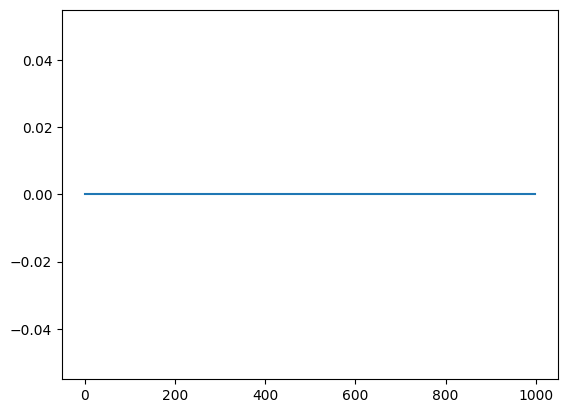

In [179]:
Q = sarsa(env)
mean_rew =evaluate(Q, env , env_render, num_episodes)
print("Mean reward over {} episodes: {}".format(num_episodes, mean_rew))